<!-- colab-badge -->
[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bmnogueira-ufms/IA-2026-02/blob/main/Aulas%20Pr%C3%A1ticas/aula01-introducao-am/aula01-gabarito.ipynb)

# Aula Prática 01 — Gabarito comentado dos exercícios

**Inteligência Artificial — Graduação**
Prof. Bruno Nogueira — FACOM/UFMS — 2026/2

---

> ⚠️ **Tente resolver os exercícios antes de ler este gabarito.** O objetivo aqui não
> é dar a resposta, e sim mostrar *um* caminho e — sobretudo — comentar **por que**
> cada conclusão se sustenta. Respostas diferentes das apresentadas podem estar
> igualmente corretas, desde que bem argumentadas.

Como nos exercícios, o código de modelagem já vem pronto: o conteúdo do gabarito está
nas **interpretações**.

Este notebook é **autocontido**: pode ser executado sem rodar o notebook da aula antes.

## Preparação (mesma da aula)

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
plt.rcParams.update({
    "figure.figsize": (7, 4.2), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10,
})
CORES = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

# --- Carregando a base de doença cardíaca ---------------------------------
CAMINHO_LOCAL = Path("../../dados/heart-cleveland.csv")
URL_FALLBACK = ("https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/"
                "master/Notebooks/Data/Heart.csv")

bruto = (pd.read_csv(CAMINHO_LOCAL) if CAMINHO_LOCAL.exists()
         else pd.read_csv(URL_FALLBACK, index_col=0))

RENOMEAR = {
    "Age": "idade", "Sex": "sexo", "ChestPain": "dor_peito", "RestBP": "pressao_repouso",
    "Chol": "colesterol", "Fbs": "glicemia_alta", "RestECG": "ecg_repouso",
    "MaxHR": "freq_card_max", "ExAng": "angina_exercicio", "Oldpeak": "depressao_st",
    "Slope": "inclinacao_st", "Ca": "n_vasos", "Thal": "talassemia", "AHD": "doenca",
}
coracao = bruto.rename(columns=RENOMEAR)
coracao["dor_peito"] = coracao["dor_peito"].map({
    "typical": "angina_tipica", "nontypical": "angina_atipica",
    "nonanginal": "dor_nao_anginosa", "asymptomatic": "assintomatico",
})
coracao["talassemia"] = coracao["talassemia"].map({
    "normal": "normal", "fixed": "defeito_fixo", "reversable": "defeito_reversivel",
})
coracao["doenca"] = (coracao["doenca"] == "Yes").astype(int)

X = coracao.drop(columns="doenca")
y = coracao["doenca"]

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

cols_categoricas = ["dor_peito", "talassemia"]
cols_numericas = [c for c in X.columns if c not in cols_categoricas]

preproc = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), cols_numericas),
    ("cat", Pipeline([
        ("imputar", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cols_categoricas),
])

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=1 / 3, random_state=RANDOM_STATE, stratify=y
)
skf10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

print(f"Base pronta: {len(X)} pacientes  |  treino {len(X_treino)}  |  teste {len(X_teste)}")

Base pronta: 303 pacientes  |  treino 202  |  teste 101


---
# Exercício 1 — Matriz de confusão na mão

**(a) A base**

In [2]:
pacientes = pd.DataFrame({
    "paciente": [f"P{i}" for i in range(1, 11)],
    "tosse":      ["SIM", "NÃO", "SIM", "SIM", "NÃO", "SIM", "NÃO", "NÃO", "NÃO", "SIM"],
    "febre":      ["NÃO", "NÃO", "NÃO", "SIM", "SIM", "NÃO", "NÃO", "SIM", "NÃO", "SIM"],
    "dor_cabeca": ["SIM", "SIM", "NÃO", "SIM", "SIM", "NÃO", "NÃO", "NÃO", "NÃO", "SIM"],
    "doente":     ["SIM", "NÃO", "NÃO", "SIM", "SIM", "SIM", "NÃO", "SIM", "NÃO", "SIM"],
    "saida":      ["NÃO", "SIM", "SIM", "NÃO", "SIM", "SIM", "SIM", "NÃO", "NÃO", "NÃO"],
    "fold":       [1, 2, 1, 2, 1, 3, 3, 2, 3, 3],
}).set_index("paciente")

pacientes["real_bin"] = (pacientes["doente"] == "SIM").astype(int)
pacientes["pred_bin"] = (pacientes["saida"] == "SIM").astype(int)
pacientes

,tosse,febre,dor_cabeca,doente,saida,fold,real_bin,pred_bin
paciente,,,,,,,,
P1,SIM,NÃO,SIM,SIM,NÃO,1,1,0
P2,NÃO,NÃO,SIM,NÃO,SIM,2,0,1
P3,SIM,NÃO,NÃO,NÃO,SIM,1,0,1
P4,SIM,SIM,SIM,SIM,NÃO,2,1,0
P5,NÃO,SIM,SIM,SIM,SIM,1,1,1
P6,SIM,NÃO,NÃO,SIM,SIM,3,1,1
P7,NÃO,NÃO,NÃO,NÃO,SIM,3,0,1
P8,NÃO,SIM,NÃO,SIM,NÃO,2,1,0
P9,NÃO,NÃO,NÃO,NÃO,NÃO,3,0,0


**(b) A matriz de confusão de cada fold**

A armadilha aqui é o argumento `labels=[0, 1]`. Um fold pode não conter exemplos de
alguma das classes; sem `labels`, o `scikit-learn` devolve uma matriz **menor que
2×2** e a soma dos folds quebra com um erro de dimensão.

In [3]:
from sklearn.metrics import confusion_matrix

matrizes = {}
for fold in sorted(pacientes["fold"].unique()):
    sub = pacientes[pacientes["fold"] == fold]
    mc_fold = confusion_matrix(sub["real_bin"], sub["pred_bin"], labels=[0, 1])
    matrizes[fold] = mc_fold

    print(f"\n--- FOLD {fold}  (pacientes: {', '.join(sub.index)}) ---")
    print(pd.DataFrame(mc_fold, index=["real −", "real +"],
                       columns=["pred −", "pred +"]).to_string())


--- FOLD 1  (pacientes: P1, P3, P5) ---
        pred −  pred +
real −       0       1
real +       1       1

--- FOLD 2  (pacientes: P2, P4, P8) ---
        pred −  pred +
real −       0       1
real +       2       0

--- FOLD 3  (pacientes: P6, P7, P9, P10) ---
        pred −  pred +
real −       1       1
real +       1       1


**(c) A matriz final é a SOMA das matrizes dos folds**

Isso funciona porque, na validação cruzada, **cada exemplo é testado exatamente uma
vez**. A soma, portanto, contém os 10 pacientes — nem mais, nem menos.

In [4]:
mc_final = sum(matrizes.values())

print("MATRIZ DE CONFUSÃO FINAL")
print(pd.DataFrame(mc_final, index=["real −", "real +"],
                   columns=["pred −", "pred +"]).to_string())
print(f"\nTotal de exemplos: {mc_final.sum()}  (confere com os 10 pacientes ✓)")

tn, fp, fn, tp = mc_final.ravel()
print(f"\nTP = {tp}   (doentes corretamente identificados)")
print(f"TN = {tn}   (saudáveis corretamente identificados)")
print(f"FP = {fp}   (saudáveis rotulados como doentes)")
print(f"FN = {fn}   (doentes rotulados como saudáveis)")

MATRIZ DE CONFUSÃO FINAL
        pred −  pred +
real −       1       3
real +       4       2

Total de exemplos: 10  (confere com os 10 pacientes ✓)

TP = 2   (doentes corretamente identificados)
TN = 1   (saudáveis corretamente identificados)
FP = 3   (saudáveis rotulados como doentes)
FN = 4   (doentes rotulados como saudáveis)


**(d) As métricas**

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

P, N = tp + fn, tn + fp
acuracia  = (tp + tn) / (P + N)
revocacao = tp / P
precisao  = tp / (tp + fp)

print(f"Acurácia  = (TP + TN) / (P + N) = ({tp} + {tn}) / {P + N} = {acuracia:.1%}")
print(f"Revocação = TP / P              = {tp} / {P}          = {revocacao:.1%}")
print(f"Precisão  = TP / (TP + FP)      = {tp} / ({tp} + {fp})     = {precisao:.1%}")

assert np.isclose(acuracia, accuracy_score(pacientes["real_bin"], pacientes["pred_bin"]))
assert np.isclose(revocacao, recall_score(pacientes["real_bin"], pacientes["pred_bin"]))
assert np.isclose(precisao, precision_score(pacientes["real_bin"], pacientes["pred_bin"]))
print("\n✓ Confere com o scikit-learn.")

Acurácia  = (TP + TN) / (P + N) = (2 + 1) / 10 = 30.0%
Revocação = TP / P              = 2 / 6          = 33.3%
Precisão  = TP / (TP + FP)      = 2 / (2 + 3)     = 40.0%

✓ Confere com o scikit-learn.


**(e) A comparação com o erro majoritário**

In [6]:
prop_majoritaria = pacientes["real_bin"].value_counts(normalize=True).max()
print(f"Classe majoritária    : 'doente = SIM' ({prop_majoritaria:.0%} dos exemplos)")
print(f"ERRO MAJORITÁRIO      : {1 - prop_majoritaria:.0%}")
print(f"Erro do classificador : {1 - acuracia:.0%}")

Classe majoritária    : 'doente = SIM' (60% dos exemplos)
ERRO MAJORITÁRIO      : 40%
Erro do classificador : 70%


### 🎯 Conclusão do Exercício 1

O classificador erra **70%** dos casos, enquanto um "modelo" idiota que rotulasse
**todo mundo como doente** erraria apenas **40%**.

> **Este classificador não aprendeu nada — é pior que o chute na classe majoritária.**

Duas observações que valem a pena:

- Numa classificação **binária**, 30% de acurácia é pior que jogar uma moeda (50%).
  Um modelo tão sistematicamente errado carrega informação: **inverter** todas as suas
  respostas produziria 70% de acurácia.
- É exatamente para flagrar situações assim que a comparação com o erro majoritário é
  obrigatória. Sem ela, alguém poderia olhar para "precisão de 40%" e achar que o
  sistema tem algum valor.

---
# Exercício 2 — Formulando um problema

*(Resposta em texto. Apresentamos uma solução para **detecção de fraude em cartão de
crédito**; qualquer um dos problemas propostos seria aceitável, desde que a
argumentação seja consistente.)*

### (a) A tripla de Mitchell

- **T (tarefa)** — decidir, para cada transação submetida, se ela é **fraudulenta** ou
  **legítima**, em tempo real (antes da autorização).
- **P (desempenho)** — **não** a acurácia. Como menos de 0,2% das transações são
  fraudes, a acurácia é inútil aqui (veja (d)). Uma medida adequada seria a
  **revocação da classe "fraude"** sujeita a um teto de falsos positivos — por exemplo,
  *"% de fraudes detectadas, mantendo abaixo de 1 em 500 o número de transações
  legítimas bloqueadas"*. Melhor ainda seria o **prejuízo financeiro evitado em reais**,
  que pondera cada erro pelo seu custo real.
- **E (experiência)** — o histórico de transações do banco com o desfecho conhecido
  (contestadas/estornadas pelo cliente = fraude; as demais = legítimas), acrescido de
  atributos de contexto: valor, horário, categoria do estabelecimento, distância
  geográfica em relação à transação anterior, desvio em relação ao padrão de gasto do
  cliente.

### (b) Qual é a tarefa?

**Classificação** — a saída é uma classe discreta (fraude / legítima), pertencente a um
conjunto predefinido de classes.

*Observação*: se o modelo devolvesse uma **probabilidade de fraude** ou um **escore de
risco contínuo**, teríamos uma saída contínua — mas a tarefa continuaria sendo
classificação, porque a decisão final (autorizar ou bloquear) é discreta. O que muda é
apenas o limiar aplicado sobre o escore, exatamente como no Exercício 6.

### (c) Qual paradigma?

Principalmente **supervisionado**, porque temos os rótulos históricos (as contestações
dos clientes funcionam como o "professor externo").

Há duas ressalvas importantes, e elas rendem uma boa discussão:

- Os rótulos são **incompletos e atrasados**: uma fraude só vira rótulo quando o
  cliente reclama, o que pode levar meses — ou nunca acontecer. Isso empurra o problema
  para o terreno **semissupervisionado**.
- Fraudadores mudam de tática o tempo todo. Por isso sistemas reais combinam o
  classificador supervisionado com **detecção de anomalias não supervisionada**, capaz
  de sinalizar padrões nunca vistos — para os quais, por definição, não existe rótulo.

### (d) Qual erro é mais caro?

| Erro | O que acontece | Custo |
|---|---|---|
| **Falso negativo** — fraude não detectada | a transação é aprovada | prejuízo direto: o banco estorna o valor |
| **Falso positivo** — transação legítima bloqueada | o cartão do cliente é recusado | constrangimento, ligação para a central, risco de perder o cliente |

O falso negativo tem custo **imediato e mensurável**; o falso positivo tem custo
**difuso, mas multiplicado pelo volume** — com milhões de transações por dia, mesmo
uma taxa baixíssima de falsos positivos irrita milhares de clientes.

**Métrica a reportar**: precisão e revocação **da classe minoritária** (fraude), a
curva precisão × revocação, e — quando o banco souber estimar os custos — o
**prejuízo esperado em reais**, que é o único jeito honesto de comparar dois erros de
naturezas diferentes.

> **Por que a acurácia é inútil aqui?** Se 99,8% das transações são legítimas, o
> classificador "nada é fraude" tem **99,8% de acurácia** e valor **zero**. O erro
> majoritário é 0,2%: bater esse número é o mínimo, não a meta. O Exercício 3 mostra
> esse mesmo fenômeno com números concretos.

---
# Exercício 3 — Três matrizes, três domínios

In [7]:
cenarios = {
    "A) Rastreamento de câncer por mamografia": dict(tp=45,  fn=5,  fp=950, tn=9000),
    "B) Filtro de spam de e-mail":              dict(tp=285, fn=15, fp=30,  tn=670),
    "C) Detecção de peça defeituosa":           dict(tp=60,  fn=40, fp=20,  tn=4880),
}

linhas = []
for nome, m in cenarios.items():
    tp_, fn_, fp_, tn_ = m["tp"], m["fn"], m["fp"], m["tn"]
    P_, N_ = tp_ + fn_, tn_ + fp_
    linhas.append({
        "cenário": nome,
        "prevalência do positivo": P_ / (P_ + N_),
        "acurácia": (tp_ + tn_) / (P_ + N_),
        "acurácia da classe majoritária": max(P_, N_) / (P_ + N_),
        "precisão": tp_ / (tp_ + fp_),
        "revocação": tp_ / P_,
        "especificidade": tn_ / N_,
    })

resumo = pd.DataFrame(linhas).set_index("cenário")
resumo["o modelo BATEU o baseline?"] = np.where(
    resumo["acurácia"] > resumo["acurácia da classe majoritária"], "sim", "NÃO")
resumo.round(4)

,prevalência do positivo,acurácia,acurácia da classe majoritária,precisão,revocação,especificidade,o modelo BATEU o baseline?
cenário,,,,,,,
A) Rastreamento de câncer por mamografia,0.005,0.9045,0.995,0.0452,0.90,0.9045,NÃO
B) Filtro de spam de e-mail,0.300,0.9550,0.700,0.9048,0.95,0.9571,sim
C) Detecção de peça defeituosa,0.020,0.9880,0.980,0.7500,0.60,0.9959,sim


### (a) e (b) — a acurácia contra o erro majoritário

| Cenário | Acurácia | Baseline (classe majoritária) | Veredito |
|---|---|---|---|
| **A** — mamografia | 90,5% | **99,5%** | ❌ **pior que o baseline** |
| **B** — spam | 95,5% | 70,0% | ✅ aprendeu, com folga |
| **C** — peça defeituosa | 98,8% | 98,0% | ⚠️ mal supera o baseline |

O caso mais enganoso é o **A**. Uma acurácia de 90,5% soa razoável — até percebermos
que um "sistema" que respondesse *"nenhuma mulher tem câncer"* acertaria **99,5%**.
Medida por acurácia, a triagem é **nove pontos percentuais pior que não fazer nada**.

O caso **C** é enganoso de outra forma, mais sutil: 98,8% parece excelente, e de fato
supera o baseline — mas por apenas 0,8 ponto. E olhar só a acurácia esconde o dado
realmente importante: a revocação é de apenas **60%**, ou seja, **40 de cada 100 peças
defeituosas chegam ao cliente**.

> A acurácia é tanto mais enganosa quanto mais **desbalanceada** for a base. Em A a
> prevalência é de 0,5%; em B, de 30%. Não por acaso, B é o único cenário em que a
> acurácia conta uma história aproximadamente honesta.

### (c) — qual erro é mais caro, e o que reportar

**A) Mamografia (rastreamento populacional)**

- **Falso negativo**: um tumor não detectado segue crescendo até o próximo
  rastreamento — potencialmente fatal.
- **Falso positivo**: exames adicionais, biópsia, semanas de ansiedade, custo.

O falso negativo é incomparavelmente mais grave. **Reporte a revocação
(sensibilidade)**, que aqui é de 90%, e informe a precisão como o custo dessa escolha.
É por isso que protocolos de rastreamento são deliberadamente calibrados para
revocação alta: eles *aceitam* muitos falsos positivos, sabendo que o exame seguinte
os filtrará.

**B) Filtro de spam**

Aqui a assimetria **se inverte**:

- **Falso positivo**: um e-mail legítimo — a proposta de emprego, o boleto, o resultado
  do exame — vai para o lixo e nunca é lido.
- **Falso negativo**: uma propaganda chata na caixa de entrada. O usuário apaga e
  segue a vida.

**Reporte a precisão** (aqui 90,5%) ou, equivalentemente, a **especificidade** (95,7%).
Nenhum usuário tolera perder correspondência importante para ganhar uma caixa de
entrada mais limpa.

**C) Peça defeituosa**

Depende de **onde** está o controle de qualidade:

- Se a peça vai para um freio de automóvel, o falso negativo é catastrófico → priorize
  **revocação** (que está em preocupantes 60%).
- Se descartar uma peça boa é caro e o defeito é cosmético, o falso positivo pesa mais
  → priorize **precisão**.

Este é o cenário que melhor ilustra a lição: **não existe métrica universalmente
correta**. A pergunta certa não é "qual métrica é a melhor?", mas *"quanto custa cada
tipo de erro neste domínio?"*.

### (d) — 1 alarme verdadeiro a cada 22. O sistema é ruim?

**Não necessariamente** — e este é um dos raciocínios mais importantes de toda a
disciplina.

In [8]:
tp_a, fn_a, fp_a, tn_a = 45, 5, 950, 9000
print(f"Precisão no cenário A: {tp_a / (tp_a + fp_a):.1%}  "
      f"→ 1 alarme verdadeiro a cada {(tp_a + fp_a) / tp_a:.0f}")
print(f"Prevalência da doença: {(tp_a + fn_a) / 10000:.1%}")
print(f"\nProbabilidade de ter câncer ANTES do exame : {(tp_a + fn_a) / 10000:.2%}")
print(f"Probabilidade de ter câncer APÓS exame positivo: {tp_a / (tp_a + fp_a):.2%}")
print(f"\n→ O exame multiplicou a probabilidade por "
      f"{(tp_a / (tp_a + fp_a)) / ((tp_a + fn_a) / 10000):.0f}×")

Precisão no cenário A: 4.5%  → 1 alarme verdadeiro a cada 22
Prevalência da doença: 0.5%

Probabilidade de ter câncer ANTES do exame : 0.50%
Probabilidade de ter câncer APÓS exame positivo: 4.52%

→ O exame multiplicou a probabilidade por 9×


A precisão baixa **não** é culpa do modelo: é consequência matemática da **prevalência
baixa**. Com apenas 50 doentes entre 10.000 mulheres, mesmo uma especificidade de
90,5% gera 950 falsos positivos — vinte vezes mais que o total de casos reais.

O que importa é que o exame **transformou uma probabilidade de 0,5% em uma
probabilidade de 4,5%**: multiplicou o risco por 9. Para uma triagem — cujo papel é
selecionar quem segue para um exame mais caro e definitivo, não dar o diagnóstico
final — isso é perfeitamente útil.

> **Moral**: precisão e revocação **não** são propriedades apenas do modelo. Elas
> dependem da **prevalência** da classe positiva. O mesmo classificador, aplicado a um
> grupo de risco (prevalência 10% em vez de 0,5%), teria precisão muito maior sem
> nenhuma mudança no algoritmo.

Isso também explica por que **não se deve comparar precisões medidas em bases com
proporções de classe diferentes** — um erro comum em trabalhos de conclusão de curso.

---
# Exercício 4 — Por que validação cruzada?

In [9]:
from sklearn.model_selection import cross_val_score

modelo_ex = Pipeline([
    ("preproc", preproc),
    ("arvore", DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)),
])

accs_hold = []
for semente in range(30):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=1/3, random_state=semente, stratify=y)
    accs_hold.append(modelo_ex.fit(Xa, ya).score(Xb, yb))
accs_hold = np.array(accs_hold)

scores_cv = cross_val_score(modelo_ex, X, y, cv=skf10, scoring="accuracy")

print(f"(a) Holdout — menor    : {accs_hold.min():.1%}")
print(f"    Holdout — maior    : {accs_hold.max():.1%}")
print(f"    Holdout — amplitude: {accs_hold.max() - accs_hold.min():.1%}")
print(f"    Holdout — desvio   : {accs_hold.std():.1%}")
print(f"\n    10-fold CV        : {scores_cv.mean():.1%} ± {scores_cv.std():.1%}")

(a) Holdout — menor    : 65.3%
    Holdout — maior    : 83.2%
    Holdout — amplitude: 17.8%
    Holdout — desvio   : 3.8%

    10-fold CV        : 79.5% ± 7.8%


### 🎯 Conclusão do Exercício 4

**(a)** A amplitude passa de **17 pontos percentuais** — e nada mudou: mesmo modelo,
mesma base, mesmos hiperparâmetros. A única diferença foi o **sorteio** de quem caiu no
treino e quem caiu no teste.

**(b) Nenhum dos dois colegas errou.** Ambos executaram o procedimento corretamente;
eles apenas sortearam divisões diferentes. O erro estaria em **reportar um único
holdout como se fosse o desempenho do modelo** — porque esse número mistura, de forma
inseparável, a qualidade do modelo e a sorte do sorteio.

Com 101 pacientes no teste, um único acerto a mais ou a menos já move a acurácia em
1 ponto percentual. A variabilidade observada é, portanto, esperada: ela vem do
**tamanho pequeno da amostra de teste**, não de nenhuma falha metodológica.

**(c) O que a validação cruzada resolve — e o que não resolve.**

✅ Resolve:

- Reduz a dependência de um sorteio único: todo exemplo é testado exatamente uma vez.
- Fornece uma estimativa **menos enviesada**, porque cada modelo treina com $(k-1)/k$
  dos dados em vez de 2/3.
- Dá uma **barra de erro** (o desvio entre os folds), que o holdout único não oferece.

❌ **Não** resolve:

- **Base pequena ou não representativa.** Se os 303 pacientes não representam a
  população de interesse, todos os folds herdam o mesmo viés. Validação cruzada mede a
  variabilidade do *sorteio*, não a do *mundo*.
- **Vazamento de dados.** Se o pré-processamento for ajustado fora do pipeline, a
  contaminação acontece dentro de cada fold e a CV não percebe.
- **Escolher hiperparâmetro espiando o teste.** É o assunto do Exercício 5.
- **Dependência temporal.** Em séries temporais, embaralhar os folds significa treinar
  com o futuro para prever o passado.

**(d) Como reportar em um artigo:**

> *"A árvore de decisão (profundidade máxima 3) obteve acurácia de
> **79,5% ± 7,8%** em validação cruzada estratificada de 10 folds, contra
> **54,1%** do classificador da classe majoritária."*

Três elementos, todos indispensáveis: a **média**, a **dispersão** e o **baseline**.
Um número sozinho não é um resultado.

---
# Exercício 5 — Diagnosticando o sobreajuste

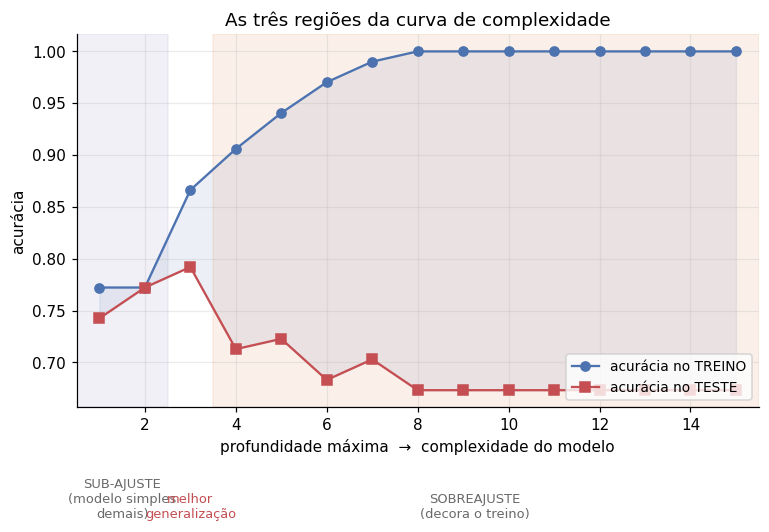

(a) Sub-ajuste : profundidades 1 a 2
    Melhor generalização: profundidade 3
    Sobreajuste: a partir da profundidade 4

(b) Acurácia no treino na profundidade máxima testada: 100.0%
    Acurácia no teste  na profundidade máxima testada: 67.3%
    Distância treino−teste: 32.7%


In [10]:
profs = list(range(1, 16))
acc_tr, acc_te = [], []
for prof in profs:
    m = Pipeline([("preproc", preproc),
                  ("arvore", DecisionTreeClassifier(max_depth=prof,
                                                    random_state=RANDOM_STATE))]).fit(X_treino, y_treino)
    acc_tr.append(m.score(X_treino, y_treino))
    acc_te.append(m.score(X_teste, y_teste))

melhor = profs[int(np.argmax(acc_te))]

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(profs, acc_tr, "o-", color=CORES[0], label="acurácia no TREINO")
ax.plot(profs, acc_te, "s-", color=CORES[3], label="acurácia no TESTE")
ax.fill_between(profs, acc_te, acc_tr, color=CORES[0], alpha=0.10)

ax.axvspan(0.5, melhor - 0.5, color=CORES[4], alpha=0.10)
ax.axvspan(melhor + 0.5, 15.5, color=CORES[1], alpha=0.12)
ax.text((0.5 + melhor - 0.5) / 2, 0.55, "SUB-AJUSTE\n(modelo simples\ndemais)",
        ha="center", fontsize=8.5, color="dimgray")
ax.text(melhor, 0.55, "melhor\ngeneralização", ha="center", fontsize=8.5, color=CORES[3])
ax.text((melhor + 15.5) / 2, 0.55, "SOBREAJUSTE\n(decora o treino)",
        ha="center", fontsize=8.5, color="dimgray")
ax.set_xlim(0.5, 15.5)
ax.set_xlabel("profundidade máxima  →  complexidade do modelo")
ax.set_ylabel("acurácia")
ax.set_title("As três regiões da curva de complexidade")
ax.legend(loc="lower right", fontsize=9)
plt.show()

print(f"(a) Sub-ajuste : profundidades 1 a {melhor - 1}")
print(f"    Melhor generalização: profundidade {melhor}")
print(f"    Sobreajuste: a partir da profundidade {melhor + 1}")
print(f"\n(b) Acurácia no treino na profundidade máxima testada: {acc_tr[-1]:.1%}")
print(f"    Acurácia no teste  na profundidade máxima testada: {acc_te[-1]:.1%}")
print(f"    Distância treino−teste: {acc_tr[-1] - acc_te[-1]:.1%}")

**(a)** As três regiões, neste experimento:

- **Sub-ajuste** — profundidades 1 e 2. A árvore é simples demais: faz um ou dois
  cortes e não consegue capturar a estrutura do problema. Repare que treino e teste
  estão **ambos baixos e próximos** — a assinatura do sub-ajuste.
- **Melhor generalização** — em torno da profundidade 3.
- **Sobreajuste** — daí em diante. O treino continua subindo até 100% enquanto o teste
  estaciona e cai. A **área sombreada** entre as curvas cresce: essa distância é a
  medida visual do sobreajuste.

**(b)** Chegar a 100% no treino não é conquista: com profundidade suficiente, a árvore
consegue isolar **cada paciente em sua própria folha**. Nesse ponto ela deixou de
aprender uma regra clínica e passou a funcionar como uma **tabela de consulta** dos 202
pacientes de treino.

O que ela faz com os pacientes atípicos é o cerne do problema: em vez de tratá-los como
**ruído** — variação natural, erro de medida, caso raro —, ela cria cortes específicos
só para acomodá-los. Esses cortes não descrevem nada de real sobre doença cardíaca;
descrevem aqueles indivíduos. E é exatamente por isso que não funcionam em pacientes
novos.

> É o mesmo fenômeno do polinômio de grau 15 da Seção 2 — muda o modelo, muda a tarefa,
> o mecanismo é idêntico.

In [11]:
from sklearn.model_selection import GridSearchCV

honestas, trapaceadas = [], []
for semente in range(25):
    Xa, Xb, ya, yb = train_test_split(X, y, test_size=1/3, random_state=semente, stratify=y)
    g = GridSearchCV(
        Pipeline([("preproc", preproc),
                  ("arvore", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
        param_grid={"arvore__max_depth": profs},
        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    ).fit(Xa, ya)
    honestas.append(g.score(Xb, yb))
    trapaceadas.append(max(
        Pipeline([("preproc", preproc),
                  ("arvore", DecisionTreeClassifier(max_depth=p,
                                                    random_state=RANDOM_STATE))]).fit(Xa, ya).score(Xb, yb)
        for p in profs
    ))

honestas, trapaceadas = np.array(honestas), np.array(trapaceadas)

print(f"Média honesta    : {honestas.mean():.1%}")
print(f"Média trapaceada : {trapaceadas.mean():.1%}")
print(f"VIÉS OTIMISTA    : {(trapaceadas - honestas).mean():+.1%}")
print(f"\nA trapaça foi otimista em {(trapaceadas > honestas).sum()} das 25 repetições;")
print(f"pessimista em {(trapaceadas < honestas).sum()};  empatada em "
      f"{(trapaceadas == honestas).sum()}.")

Média honesta    : 75.1%
Média trapaceada : 79.0%
VIÉS OTIMISTA    : +4.0%

A trapaça foi otimista em 20 das 25 repetições;
pessimista em 0;  empatada em 5.


### 🎯 Conclusão do Exercício 5

**(c)** A trapaça produz, em média, um número **maior** — e, o que é mais revelador,
ela **nunca** produz um número menor. Isso não é coincidência: é consequência
matemática de tomar o **máximo** de 15 tentativas medidas no mesmo conjunto de teste.

Cada uma dessas 15 medições contém uma parcela de **ruído** (com apenas 101 pacientes
no teste, a acurácia flutua alguns pontos por puro acaso). Ao selecionar a maior de
todas, você não escolhe apenas o melhor modelo — escolhe também **a maior flutuação
favorável**. O modelo é o mesmo; o que muda é que o número reportado absorveu a sorte.

**(d)** Seria desonesto porque o número **deixa de significar o que promete
significar**. Quando reportamos "acurácia no teste", o leitor entende: *"é isto que
esperamos que aconteça com pacientes novos"*. Mas, se o conjunto de teste participou da
escolha da profundidade, ele não é mais composto de dados não vistos — e a estimativa
passa a ser sistematicamente otimista.

A intenção não importa. É como calibrar uma balança olhando o resultado que se deseja:
mesmo sem má-fé, o instrumento deixa de medir. Por isso o teste deve ser usado **uma
única vez**, ao final, e toda escolha de hiperparâmetro deve acontecer **dentro** do
treino — por validação cruzada, ou reservando um terceiro conjunto de **validação**.

> Repare também que a curva de validação da profundidade é quase **plana** entre
> vários valores. Quando as opções empatam dentro da barra de erro, aplique a
> **Navalha de Ockham**: fique com a árvore mais **rasa**. Ela generaliza melhor,
> treina mais rápido e é mais fácil de explicar ao cardiologista.

---
# Exercício 6 — A decisão clínica

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve

modelo_prob = Pipeline([
    ("preproc", preproc),
    ("escala", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(max_iter=1000)),
]).fit(X_treino, y_treino)

probs = modelo_prob.predict_proba(X_teste)[:, 1]

pontos = []
for t in [0.10, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    pred = (probs >= t).astype(int)
    m = confusion_matrix(y_teste, pred, labels=[0, 1])
    pontos.append({
        "limiar": t,
        "TP": m[1, 1], "FN": m[1, 0], "FP": m[0, 1],
        "revocação": recall_score(y_teste, pred, zero_division=0),
        "precisão": precision_score(y_teste, pred, zero_division=0),
        "acurácia": accuracy_score(y_teste, pred),
    })
tabela_pontos = pd.DataFrame(pontos)

atende = tabela_pontos[tabela_pontos["revocação"] >= 0.90]
escolhido = atende.loc[atende["limiar"].idxmax()]
padrao = tabela_pontos[tabela_pontos["limiar"] == 0.50].iloc[0]

print(tabela_pontos.round(3).to_string(index=False))
print(f"\n(a) Maior limiar com revocação ≥ 0,90: {escolhido['limiar']:.2f}")

 limiar  TP  FN  FP  revocação  precisão  acurácia
   0.10  46   0  30      1.000     0.605     0.703
   0.20  43   3  24      0.935     0.642     0.733
   0.25  43   3  19      0.935     0.694     0.782
   0.30  41   5  18      0.891     0.695     0.772
   0.40  41   5  12      0.891     0.774     0.832
   0.50  40   6   6      0.870     0.870     0.881
   0.60  36  10   4      0.783     0.900     0.861
   0.70  33  13   3      0.717     0.917     0.842
   0.80  29  17   1      0.630     0.967     0.822

(a) Maior limiar com revocação ≥ 0,90: 0.25


**(a)** O maior limiar que atende à exigência é o indicado acima.

Queremos o **maior** — e não o menor — porque a revocação cresce monotonicamente à
medida que baixamos o limiar, mas **às custas de mais alarmes falsos**. Qualquer limiar
abaixo do escolhido também satisfaria o hospital, e no limite bastaria classificar
**todo mundo** como doente para obter revocação 1,00. Isso atenderia à regra e seria
clinicamente inútil.

> **A exigência é uma restrição, não um objetivo.** Satisfaça-a com o **menor custo
> possível** — ou seja, no ponto mais à direita que ainda cumpre a regra.

In [13]:
print(f"(b) Comparação entre as duas políticas:\n")
print(f"{'':<26}{'limiar 0,50':>14}{'limiar clínico':>16}")
print("-" * 56)
for campo in ["TP", "FN", "FP"]:
    print(f"{campo:<26}{padrao[campo]:>14.0f}{escolhido[campo]:>16.0f}")
for campo in ["revocação", "precisão", "acurácia"]:
    print(f"{campo:<26}{padrao[campo]:>14.3f}{escolhido[campo]:>16.3f}")

print(f"\nDoentes encontrados a mais : {escolhido['TP'] - padrao['TP']:.0f}")
print(f"Alarmes falsos a mais      : {escolhido['FP'] - padrao['FP']:.0f}")
print(f"Custo: {(escolhido['FP'] - padrao['FP']) / max(escolhido['TP'] - padrao['TP'], 1):.1f} "
      f"alarmes falsos por doente adicional encontrado")

(b) Comparação entre as duas políticas:

                             limiar 0,50  limiar clínico
--------------------------------------------------------
TP                                    40              43
FN                                     6               3
FP                                     6              19
revocação                          0.870           0.935
precisão                           0.870           0.694
acurácia                           0.881           0.782

Doentes encontrados a mais : 3
Alarmes falsos a mais      : 13
Custo: 4.3 alarmes falsos por doente adicional encontrado


### 🎯 Conclusão do Exercício 6

**(b)** O ganho é modesto em número absoluto de doentes encontrados, e o custo em
alarmes falsos é considerável. É precisamente esse o compromisso que a curva
precisão × revocação torna visível: **perto do extremo da curva, cada doente adicional
custa cada vez mais caro**.

**(c) A acurácia piorar não significa que a decisão está errada.** Significa que a
acurácia **não é a métrica adequada a este problema**.

A acurácia trata um falso positivo e um falso negativo como equivalentes — cada um
conta como "um erro". Mas no contexto clínico eles não são nem remotamente
equivalentes: um custa um exame adicional; o outro pode custar uma vida. Ao mudar o
limiar, trocamos deliberadamente erros caros por erros baratos. A acurácia, cega a essa
distinção, registra a troca como piora.

> Se a métrica que você otimiza discorda da decisão que o domínio exige, o problema
> está na métrica.

**(d)** Quem escolhe o ponto de operação é o **corpo clínico**, não o cientista de
dados.

A curva é um objeto **técnico**: ela descreve fielmente todos os compromissos que este
modelo pode oferecer, e produzi-la é responsabilidade de quem modela. Mas *escolher um
ponto* sobre ela é uma decisão **de política e de valores**, que depende de perguntas
que nenhum dado responde:

- Quanto custa um exame confirmatório desnecessário — em dinheiro, em fila de espera,
  em ansiedade do paciente?
- Qual o dano esperado de um infarto não prevenido?
- O hospital tem capacidade instalada para absorver o volume extra de encaminhamentos?

> **O papel do cientista de dados é apresentar a curva e explicar honestamente o
> trade-off. O papel do especialista do domínio é escolher o ponto.** Confundir os dois
> papéis é uma das falhas éticas mais comuns em projetos de AM aplicados à saúde, ao
> crédito e à justiça.

---
# Exercício 7 — Quando a classe é contínua (regressão)

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.tree import DecisionTreeRegressor

X_reg = coracao.drop(columns=["freq_card_max"])
y_reg = coracao["freq_card_max"]

cols_cat_r = ["dor_peito", "talassemia"]
cols_num_r = [c for c in X_reg.columns if c not in cols_cat_r]
preproc_reg = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), cols_num_r),
    ("cat", Pipeline([("imputar", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cols_cat_r),
])

kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
regressores = {
    "Baseline (prever sempre a média)": None,
    "Regressão Linear": LinearRegression(),
    "Árvore de Regressão (prof. 3)": DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE),
    "Árvore de Regressão (sem limite)": DecisionTreeRegressor(random_state=RANDOM_STATE),
}

res_reg, preds_reg = [], {}
for nome, est in regressores.items():
    pred = (np.full(len(y_reg), y_reg.mean()) if est is None
            else cross_val_predict(Pipeline([("preproc", preproc_reg), ("reg", est)]),
                                   X_reg, y_reg, cv=kf))
    preds_reg[nome] = pred
    erro = y_reg - pred
    res_reg.append({
        "modelo": nome,
        "MAE (bpm)": np.abs(erro).mean(),
        "RMSE (bpm)": np.sqrt((erro ** 2).mean()),
        "R²": 1 - (erro ** 2).sum() / ((y_reg - y_reg.mean()) ** 2).sum(),
    })

tabela_reg = pd.DataFrame(res_reg).round(3)
print(tabela_reg.to_string(index=False))
melhor_reg = tabela_reg.loc[tabela_reg["MAE (bpm)"].idxmin()]
print(f"\nMelhor modelo: {melhor_reg['modelo']}  (MAE = {melhor_reg['MAE (bpm)']:.1f} bpm)")

                          modelo  MAE (bpm)  RMSE (bpm)     R²
Baseline (prever sempre a média)     18.450      22.837  0.000
                Regressão Linear     14.863      18.921  0.314
   Árvore de Regressão (prof. 3)     14.498      18.761  0.325
Árvore de Regressão (sem limite)     20.657      26.080 -0.304

Melhor modelo: Árvore de Regressão (prof. 3)  (MAE = 14.5 bpm)


### 🎯 Conclusão do Exercício 7

**(a) Por que não acurácia.** Acurácia é a fração de acertos **exatos**, e só faz
sentido quando existe uma noção binária de certo e errado. Numa saída contínua, acertar
exatamente 152,0 bpm tem probabilidade praticamente nula — a acurácia seria sempre ~0%
e não distinguiria um modelo que erra por 0,3 bpm de outro que erra por 40 bpm.

Prever 152,3 quando o real é 152,0 não é "errado": é **quase exato**. Precisamos de
métricas que meçam a **magnitude** do erro, e não a sua mera existência.

| Métrica | O que mede | Unidade |
|---|---|---|
| **MAE** | erro médio absoluto | bpm (interpretável direto) |
| **RMSE** | idem, penalizando mais os erros grandes | bpm |
| **$R^2$** | fração da variância explicada | adimensional |

**(b) Interpretação clínica do MAE.** O melhor modelo erra, em média, cerca de
**14–15 batimentos por minuto** para mais ou para menos. Para dimensionar: a frequência
cardíaca máxima na base varia de 71 a 202 bpm, e o desvio padrão é de aproximadamente
23 bpm. Ou seja, o modelo é claramente melhor que um chute — mas o erro típico ainda é
grande demais para uso clínico individual.

Note o contraste entre MAE e RMSE: o RMSE é sempre maior, e a diferença entre os dois
indica a presença de alguns erros grandes puxando a média quadrática para cima.

**(c) $R^2 = 0$ e $R^2$ negativo.**

O $R^2$ compara o modelo com um referencial fixo: **prever sempre a média**.

- $R^2 = 1$ → predição perfeita.
- $R^2 = 0$ → o modelo é **exatamente tão bom quanto prever a média**. É por isso que o
  baseline tem $R^2$ igual a zero *por construção*: ele **é** a média. O $R^2$ é, para
  a regressão, o análogo do erro majoritário na classificação.
- $R^2 < 0$ → o modelo é **pior que prever a média**.

Como um modelo consegue ser pior que a média? Justamente por **sobreajuste**. A árvore
sem limite de profundidade cria uma folha para praticamente cada paciente do treino, e
ao ser aplicada a um paciente novo devolve o valor de um vizinho arbitrário do treino —
uma predição que pode estar muito distante. A média, ao menos, está sempre no centro da
distribuição e nunca erra de forma espetacular.

> É o mesmo sobreajuste da Seção 2 e do Exercício 5, agora com um sintoma novo e
> particularmente eloquente: o modelo **piora** o desempenho em relação a não modelar
> nada.

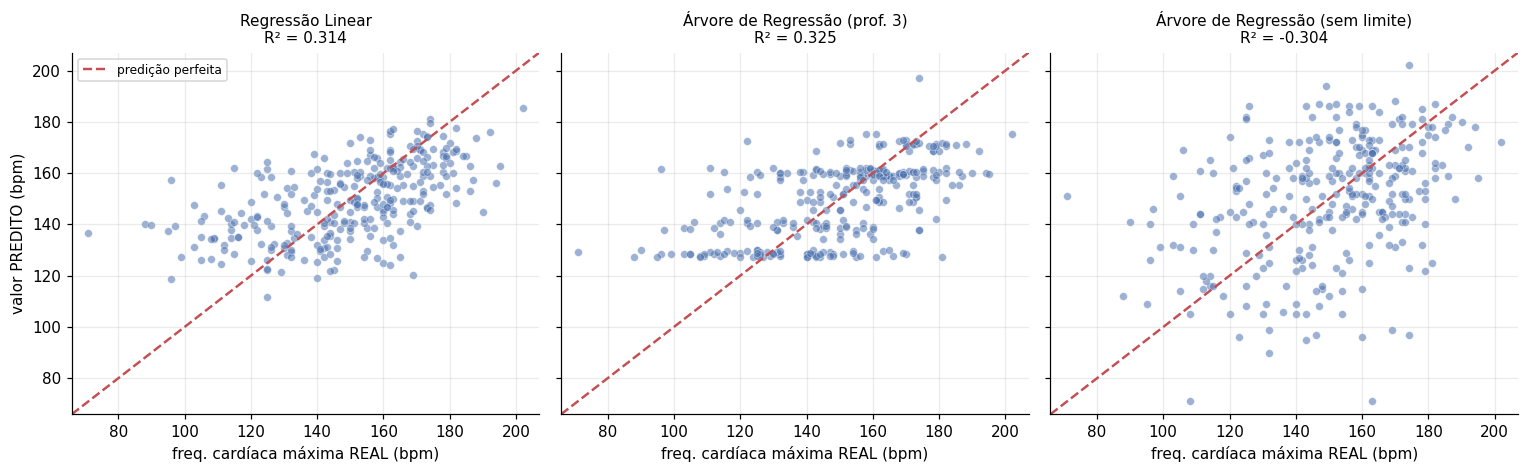

Valores distintos previstos pela árvore de profundidade 3: 70
(uma árvore de profundidade 3 tem no máximo 8 folhas — mas aqui há 10 modelos,
 um por fold da validação cruzada, e cada um tem as suas próprias folhas.)


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), sharex=True, sharey=True)
for ax, nome in zip(axes, ["Regressão Linear", "Árvore de Regressão (prof. 3)",
                           "Árvore de Regressão (sem limite)"]):
    pred = preds_reg[nome]
    ax.scatter(y_reg, pred, s=26, alpha=0.55, color=CORES[0], edgecolor="white", linewidth=0.4)
    lims = [y_reg.min() - 5, y_reg.max() + 5]
    ax.plot(lims, lims, ls="--", color=CORES[3], lw=1.6, label="predição perfeita")
    r2 = 1 - ((y_reg - pred) ** 2).sum() / ((y_reg - y_reg.mean()) ** 2).sum()
    ax.set_title(f"{nome}\nR² = {r2:.3f}", fontsize=10)
    ax.set_xlabel("freq. cardíaca máxima REAL (bpm)")
    ax.set_xlim(lims); ax.set_ylim(lims)
axes[0].set_ylabel("valor PREDITO (bpm)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

n_valores = len(np.unique(np.round(preds_reg["Árvore de Regressão (prof. 3)"], 6)))
print(f"Valores distintos previstos pela árvore de profundidade 3: {n_valores}")
print("(uma árvore de profundidade 3 tem no máximo 8 folhas — mas aqui há 10 modelos,")
print(" um por fold da validação cruzada, e cada um tem as suas próprias folhas.)")

**(d) O gráfico de valor real × predito.**

Um modelo perfeito produziria **todos os pontos exatamente sobre a diagonal tracejada**
— uma reta a 45°, sem dispersão alguma. Quanto mais espalhada a nuvem em torno dela,
pior o modelo. Essa é a leitura mais rápida e honesta de um regressor.

As **faixas horizontais** da árvore de profundidade 3 revelam a natureza do modelo:
uma árvore prevê, para cada folha, a **média dos exemplos de treino que caíram ali**.
Todos os pacientes que percorrem o mesmo caminho de decisão recebem, portanto, **o
mesmo valor** — daí as faixas. Uma árvore de profundidade 3 tem no máximo 8 folhas,
logo no máximo 8 valores possíveis por modelo.

A regressão linear, ao contrário, calcula uma combinação linear dos atributos e produz
um valor contínuo diferente para cada paciente — daí a nuvem lisa e inclinada.

> Vale notar que o $R^2$ é modesto em todos os casos, e isso é **honesto e esperado**:
> a frequência cardíaca máxima depende fortemente de condicionamento físico, medicação
> e genética — informações que simplesmente **não estão** nesta base. Nenhum algoritmo
> inventa informação que não foi coletada.

---
# Exercício 8 — Desafio: e sem rótulo nenhum?

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

X_sem_rotulo = coracao.drop(columns="doenca")

grupos_ex = Pipeline([
    ("preproc", preproc),
    ("escala", StandardScaler(with_mean=False)),
    ("kmeans", KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE)),
]).fit(X_sem_rotulo)["kmeans"].labels_

tab = pd.crosstab(grupos_ex, coracao["doenca"],
                  rownames=["grupo descoberto"], colnames=["classe real"])
tab.columns = ["saudável (0)", "doente (1)"]
print(tab.to_string())

ari = adjusted_rand_score(coracao["doenca"], grupos_ex)
print(f"\nÍndice de Rand Ajustado: {ari:.3f}")

# Alinhamos cada grupo à classe majoritária dentro dele — SÓ para medir a concordância.
mapa = tab.values.argmax(axis=1)
concordancia = (np.array([mapa[g] for g in grupos_ex]) == coracao["doenca"]).mean()
print(f"Concordância após alinhar os rótulos: {concordancia:.1%}")
print(f"Erro majoritário da base: "
      f"{1 - coracao['doenca'].value_counts(normalize=True).max():.1%}")

                  saudável (0)  doente (1)
grupo descoberto                          
0                           24         113
1                          140          26

Índice de Rand Ajustado: 0.447
Concordância após alinhar os rótulos: 83.5%
Erro majoritário da base: 45.9%


       idade média  freq. card. máx.  nº vasos  depressão ST  pressão repouso  prop. masculino  prop. doentes
grupo                                                                                                        
0            57.01            137.40      1.12          1.67           133.38             0.85           0.82
1            52.31            159.68      0.30          0.52           130.30             0.54           0.16


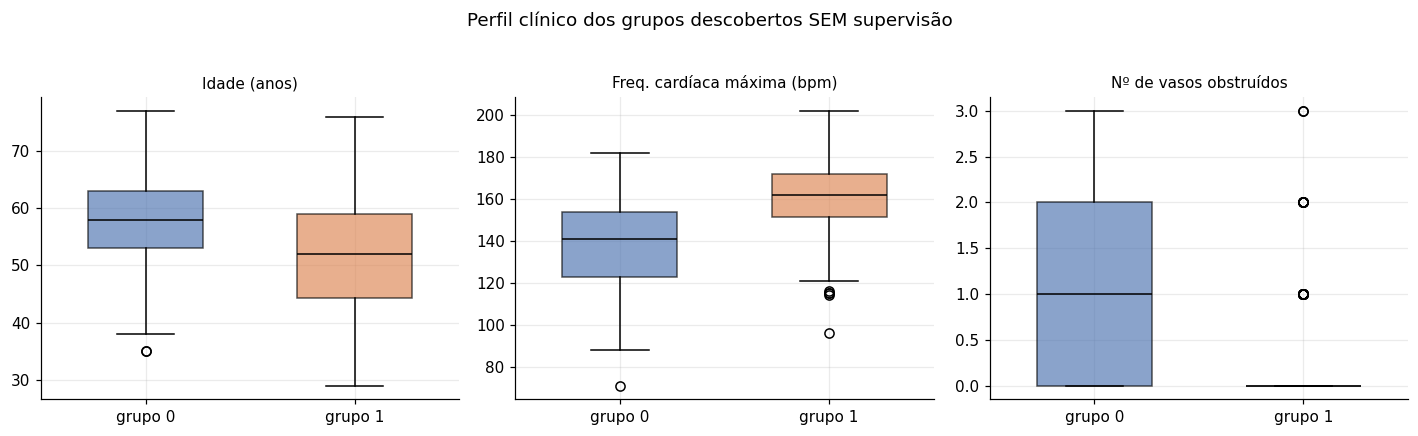

In [17]:
perfil = coracao.assign(grupo=grupos_ex).groupby("grupo")[
    ["idade", "freq_card_max", "n_vasos", "depressao_st", "pressao_repouso", "sexo", "doenca"]
].mean()
perfil.columns = ["idade média", "freq. card. máx.", "nº vasos", "depressão ST",
                  "pressão repouso", "prop. masculino", "prop. doentes"]
print(perfil.round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, col, titulo in zip(axes, ["idade", "freq_card_max", "n_vasos"],
                           ["Idade (anos)", "Freq. cardíaca máxima (bpm)",
                            "Nº de vasos obstruídos"]):
    dados = [coracao.loc[grupos_ex == g, col].dropna() for g in (0, 1)]
    bp = ax.boxplot(dados, patch_artist=True, widths=0.55)
    ax.set_xticks([1, 2], ["grupo 0", "grupo 1"])
    for patch, cor in zip(bp["boxes"], [CORES[0], CORES[1]]):
        patch.set_facecolor(cor); patch.set_alpha(0.65)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_title(titulo, fontsize=10)
fig.suptitle("Perfil clínico dos grupos descobertos SEM supervisão", y=1.03)
plt.tight_layout()
plt.show()

### 🎯 Conclusão do Exercício 8

**(a) e (b)** Sim — em larga medida. Sem jamais ter visto um diagnóstico, o K-Means
separou os pacientes em dois grupos que concordam com a classe real em cerca de **83%**
dos casos, bem acima do que se esperaria por acaso (o Índice de Rand Ajustado fica em
torno de 0,45; zero seria concordância ao acaso).

Os perfis são **clinicamente coerentes**: um dos grupos concentra pacientes mais
velhos, com frequência cardíaca máxima menor, mais vasos obstruídos e maior depressão
do segmento ST — exatamente o perfil de risco cardiovascular. O algoritmo não sabia
nada disso; ele apenas encontrou dois aglomerados no espaço de atributos, e esses
aglomerados **correspondem** à distinção clínica.

É esse fenômeno que torna o aprendizado não supervisionado valioso: em domínios onde
rotular custa caro — ou onde ainda nem sabemos quais são as categorias certas — ele
revela estrutura que **já estava nos dados**. Foi assim que subtipos de câncer e perfis
de consumidores foram descobertos.

**(c) Por que não calcular acurácia diretamente.**

Porque **os rótulos dos grupos são arbitrários**. O K-Means poderia igualmente ter
chamado de "grupo 0" aquilo que chamou de "grupo 1": a partição seria **idêntica**, e a
acurácia saltaria de cerca de 83% para cerca de 17%. Uma métrica que muda de valor
quando você renomeia as categorias não está medindo a qualidade do agrupamento — está
medindo uma convenção de nomes.

(Note que, no código acima, precisamos **alinhar** cada grupo à classe majoritária
dentro dele antes de calcular a concordância. Esse alinhamento é uma decisão *nossa*,
tomada depois de olhar os rótulos — e por isso o número resultante deve ser lido com
cautela.)

Por isso usamos medidas **invariantes a permutação de rótulos**, como o **Índice de
Rand Ajustado**, que conta pares de pontos que ficaram juntos ou separados nas duas
partições e é corrigido para o acaso.

**(d) Como avaliar sem rótulos.**

Num problema genuinamente não supervisionado, a coluna `doenca` não existiria — e nem
o ARI nem a concordância poderiam ser calculados. Restam três caminhos, todos
imperfeitos:

1. **Medidas internas**, que avaliam a geometria da partição: coeficiente de
   **silhueta** (quão mais próximo cada ponto está do seu grupo do que do vizinho),
   inércia, índice de Davies-Bouldin. Elas medem se os grupos são *compactos e
   separados* — mas não se são **úteis**.
2. **Estabilidade**: reamostre os dados e verifique se os mesmos grupos reaparecem.
   Um agrupamento que muda completamente a cada reamostragem provavelmente está
   descrevendo ruído.
3. **Julgamento do especialista do domínio** — na prática, o mais decisivo. Um
   cardiologista olha o perfil dos grupos e diz se aquilo corresponde a algo real. Foi
   o que fizemos, informalmente, no item (b).

> Em aprendizado não supervisionado **não existe resposta certa objetiva**. É por isso
> que ele costuma ser usado para *explorar* e *gerar hipóteses*, e não para tomar
> decisões automáticas sozinho.

---
## Onde continuamos

Os exercícios deixaram três perguntas em aberto, que a próxima aula responde:

- **Como** a árvore decide onde cortar? (entropia, ganho de informação, índice Gini)
- Como funcionam por dentro os classificadores que usamos aqui como caixa-preta —
  KNN, Naive Bayes, regressão logística?
- Como comparar dois modelos com **rigor estatístico**, e não no olhômetro?